Phase 1: Connect Google Drive

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Phase 2: Extract Dataset

Check ZIP File

In [ ]:
!ls "/content/drive/MyDrive"

 1741188570941.jpg
 1741454490399.png
'AI-Lab13 (1).docx'
'AI-Lab13 (2).docx'
'AI-Lab13 (3).docx'
 AI-Lab13.docx
 archive.zip
'Assignment 02 Applied Physics (1).gdoc'
'Assignment 02 Applied Physics (2).gdoc'
'Assignment 02 Applied Physics (3).gdoc'
'Assignment 02 Applied Physics.gdoc'
'Assignment 03 Applied Physics (1).gdoc'
'Assignment 03 Applied Physics (2).gdoc'
'Assignment 03 Applied Physics (3).gdoc'
'Assignment 03 Applied Physics.gdoc'
'Assignment 04 Applied Physics (1).gdoc'
'Assignment 04 Applied Physics.gdoc'
 Assignment-3-OOP-Spring-2025.gdoc
'BSc (Hons) Computer Science III (Batch 2024).xlsx'
'C++ for Everyone (1).gdoc'
'C++ for Everyone.gdoc'
 Classroom
 COAL-LAB3-PART5.gdoc
'Colab Notebooks'
 DB-LABWEEK13-MAKEUP-PART1.docx
 Discrete_Mathematics_and_Its_Applications_7th_Edition_Rosen.gdoc
'Discriptive Statistics.gslides'
'Expository writing (SDG3).gdoc'
 F2024-0506-B-LAB-9.ipynb
'F2024-0506 (URWA AHMAD).docx'
'Fill this template for each functional requiremen....gsheet'
 Fu

Extract Dataset

In [ ]:
!rm -rf dataset

In [ ]:
!unzip "/content/drive/MyDrive/archive.zip" -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/content/unified_dataset/trash/image_03947_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03948_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03949_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03950_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03951_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03952_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03953_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03954_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03955_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03956_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03957_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03958_aug.jpg  
  inflating: dataset/content/unified_dataset/trash/image_03959_aug.jpg  


Verify Dataset

In [ ]:
!ls dataset/content/unified_dataset

battery  glass	metal  organic_waste  paper_cardboard  plastic	textiles  trash


Phase 3: Import Libraries

Import Packages

In [ ]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Phase 4: Load Images

Create X and y

In [ ]:
import os
import cv2
import numpy as np

dataset_path = "dataset/content/unified_dataset"

X = []
y = []

for category in os.listdir(dataset_path):

    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):

        for image_name in os.listdir(category_path):

            image_path = os.path.join(category_path, image_name)

            img = cv2.imread(image_path)

            if img is not None:

                img = cv2.resize(img, (64,64))

                img = img.flatten()

                X.append(img)

                y.append(category)

print("Images Loaded Successfully")

Images Loaded Successfully


Phase 5: Convert to NumPy Arrays

In [ ]:
X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (64000, 12288)
y Shape: (64000,)


Verify Classes

In [ ]:
print(np.unique(y))

['battery' 'glass' 'metal' 'organic_waste' 'paper_cardboard' 'plastic'
 'textiles' 'trash']


Phase 6: Create Balanced Sample

In [ ]:
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    X,
    y,
    train_size=10000,
    stratify=y,
    random_state=42
)

print(X_small.shape)
print(y_small.shape)

(10000, 12288)
(10000,)


Verify Sample Classes

In [ ]:
print(np.unique(y_small))

['battery' 'glass' 'metal' 'organic_waste' 'paper_cardboard' 'plastic'
 'textiles' 'trash']


Phase 7: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8000, 12288)
Testing: (2000, 12288)


Phase 8: Train Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Training Complete")

Training Complete


Phase 9: Test Accuracy

In [ ]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.487


Phase 10: Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

        battery       0.56      0.58      0.57       250
          glass       0.41      0.42      0.42       250
          metal       0.39      0.31      0.34       250
  organic_waste       0.48      0.57      0.52       250
paper_cardboard       0.50      0.43      0.46       250
        plastic       0.42      0.33      0.37       250
       textiles       0.58      0.63      0.60       250
          trash       0.52      0.62      0.57       250

       accuracy                           0.49      2000
      macro avg       0.48      0.49      0.48      2000
   weighted avg       0.48      0.49      0.48      2000



Phase 11: Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[144  23  13  21   9  13  12  15]
 [ 17 106  17  22  17  18  12  41]
 [ 24  34  77  36  15  25  16  23]
 [ 17  17  16 143  23  11  17   6]
 [ 13  23  22  33 107  17  22  13]
 [ 16  20  22  23  19  83  26  41]
 [ 19  12  12  12  15  16 158   6]
 [  7  23  19   9  11  14  11 156]]


Phase 12: Save Model

In [ ]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


Verify Model File

In [ ]:
!ls

dataset  drive	random_forest_model.pkl  sample_data


Confusion Matrix

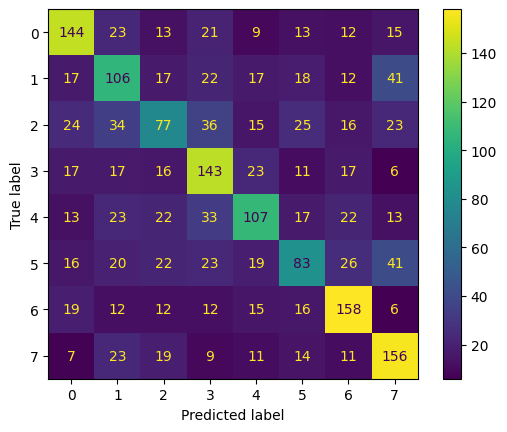

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.savefig("confusion_matrix.png")

plt.show()

In [52]:
import os

dataset_path = "dataset/content/unified_dataset/plastic"

print(os.listdir(dataset_path)[:10])

['image_18410_gd.jpg', 'image_02054_hw.jpg', 'image_02525_hw.jpg', 'image_18501_gd.jpg', 'image_00332_hw.jpg', 'image_17905_gd.jpg', 'image_00420_hw.jpg', 'image_06647_aug.jpg', 'image_19637_gd.jpg', 'image_18054_gd.jpg']


In [53]:
import os
import cv2

image_path = "dataset/content/unified_dataset/plastic/" + os.listdir("dataset/content/unified_dataset/plastic")[0]

print('image_18410_gd.jpg')

image_18410_gd.jpg


In [55]:
test_image = cv2.imread(image_path)

test_image = cv2.resize(test_image, (64,64))

test_image = test_image.flatten()

test_image = test_image.reshape(1,-1)

prediction = rf.predict(test_image)

print("Predicted Class:", prediction[0])

Predicted Class: plastic


In [56]:
from google.colab import files

uploaded = files.upload()

Saving image to recognise.jpg to image to recognise.jpg


In [62]:
print(uploaded.keys())

dict_keys(['image to recognise.jpg'])


In [63]:
image_name = list(uploaded.keys())[0]

print(image_name)

image to recognise.jpg


In [66]:
import os
import cv2

glass_folder = "dataset/content/unified_dataset/glass"

image_path = os.path.join(
    glass_folder,
    os.listdir(glass_folder)[0]
)

test_image = cv2.imread(image_path)

test_image = cv2.resize(test_image, (64,64))

test_image = test_image.flatten()

test_image = test_image.reshape(1,-1)

prediction = rf.predict(test_image)

print("Prediction:", prediction[0])

Prediction: glass


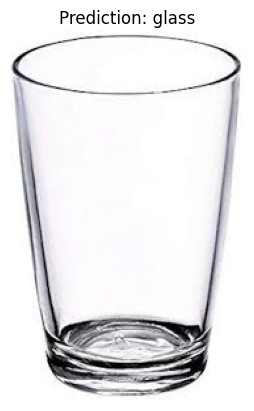

In [68]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(image_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(f"Prediction: {prediction[0]}")
plt.axis("off")
plt.show()